# Tutorial 01: Khám phá tín hiệu rung CWRU
> Mục tiêu: Làm quen với dữ liệu rung ổ lăn, hiểu cấu trúc file, vẽ và đọc dạng sóng.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12

DATA_ROOT = "./data"   # Thư mục chứa file .npy
SAMPLE_RATE = 12000    # 12 kHz
print("OK!")


OK!


## 1. Đọc file .npy

Mỗi file `.npy` chứa **tín hiệu gia tốc rung** (đơn vị: g) đo tại vị trí Drive End (DE) — gần ổ lăn nhất.

**Quy ước tên file:** `<LoạiLỗi>_<KíchThước>_DE.npy`
- `Normal_DE.npy` → Bình thường
- `IR_007_DE.npy` → Lỗi rãnh trong, đường kính 7 mils
- `OR_007@6_DE.npy` → Lỗi rãnh ngoài, vị trí 6 giờ
- `B_007_DE.npy` → Lỗi bi


In [2]:
# Đọc 1 file bình thường và 1 file lỗi
normal = np.load(os.path.join(DATA_ROOT, "0HP", "Normal_DE.npy"))
ir_007 = np.load(os.path.join(DATA_ROOT, "0HP", "IR_007_DE.npy"))

print(f"Normal: {len(normal)} mẫu = {len(normal)/SAMPLE_RATE:.1f} giây")
print(f"IR_007: {len(ir_007)} mẫu = {len(ir_007)/SAMPLE_RATE:.1f} giây")
print(f"\nVài giá trị đầu (Normal): {normal[:5]}")


Normal: 243938 mẫu = 20.3 giây
IR_007: 243938 mẫu = 20.3 giây

Vài giá trị đầu (Normal): [ 0.05319692  0.08866154  0.09971815  0.05862092 -0.00458954]


## 2. Vẽ dạng sóng (Waveform)

Dạng sóng cho thấy **biên độ rung theo thời gian**. Ổ lăn hỏng sẽ tạo ra xung va chạm lặp lại.


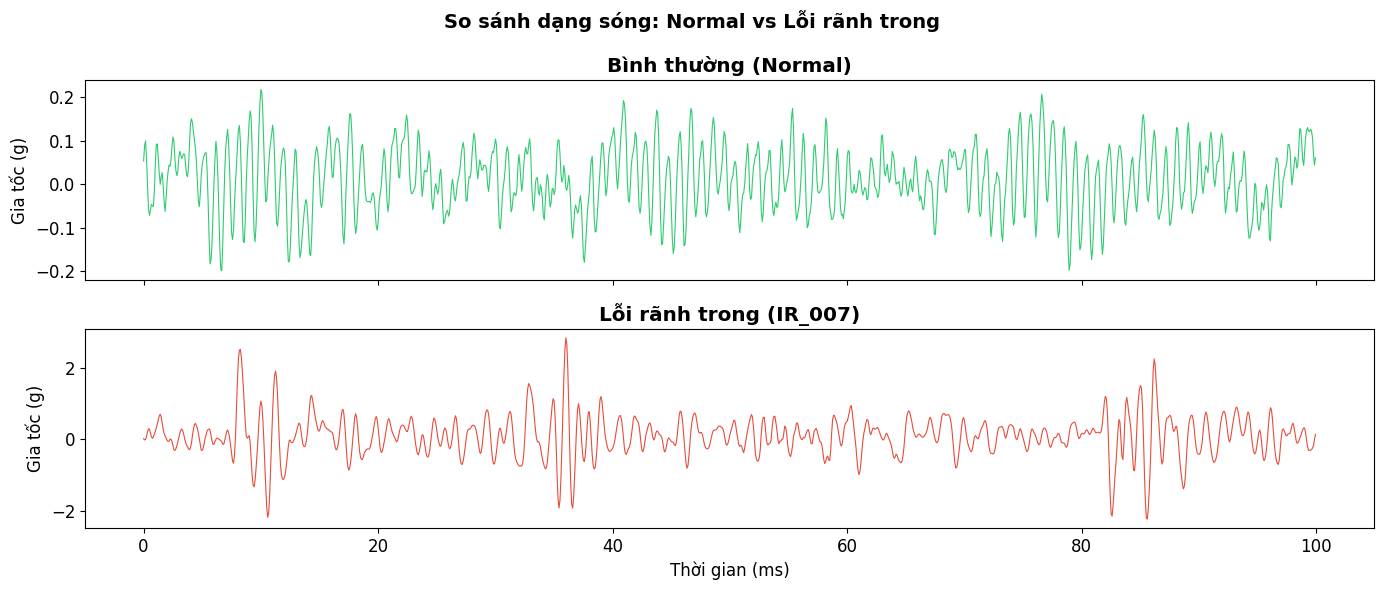

Nhận xét:
- Normal: biên độ nhỏ, dao động đều
- IR_007: xuất hiện xung va chạm lặp lại, biên độ lớn hơn


In [3]:
# Vẽ 0.1 giây đầu (1200 mẫu) để dễ quan sát
n_show = 1200
t = np.arange(n_show) / SAMPLE_RATE * 1000  # đổi sang ms

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(t, normal[:n_show], color='#2ecc71', linewidth=0.8)
axes[0].set_title('Bình thường (Normal)', fontweight='bold')
axes[0].set_ylabel('Gia tốc (g)')

axes[1].plot(t, ir_007[:n_show], color='#e74c3c', linewidth=0.8)
axes[1].set_title('Lỗi rãnh trong (IR_007)', fontweight='bold')
axes[1].set_ylabel('Gia tốc (g)')
axes[1].set_xlabel('Thời gian (ms)')

plt.suptitle('So sánh dạng sóng: Normal vs Lỗi rãnh trong', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Nhận xét:")
print("- Normal: biên độ nhỏ, dao động đều")
print("- IR_007: xuất hiện xung va chạm lặp lại, biên độ lớn hơn")


## 3. So sánh 4 trạng thái

Vẽ đồng thời Normal, lỗi rãnh trong (IR), lỗi rãnh ngoài (OR), lỗi bi (B).


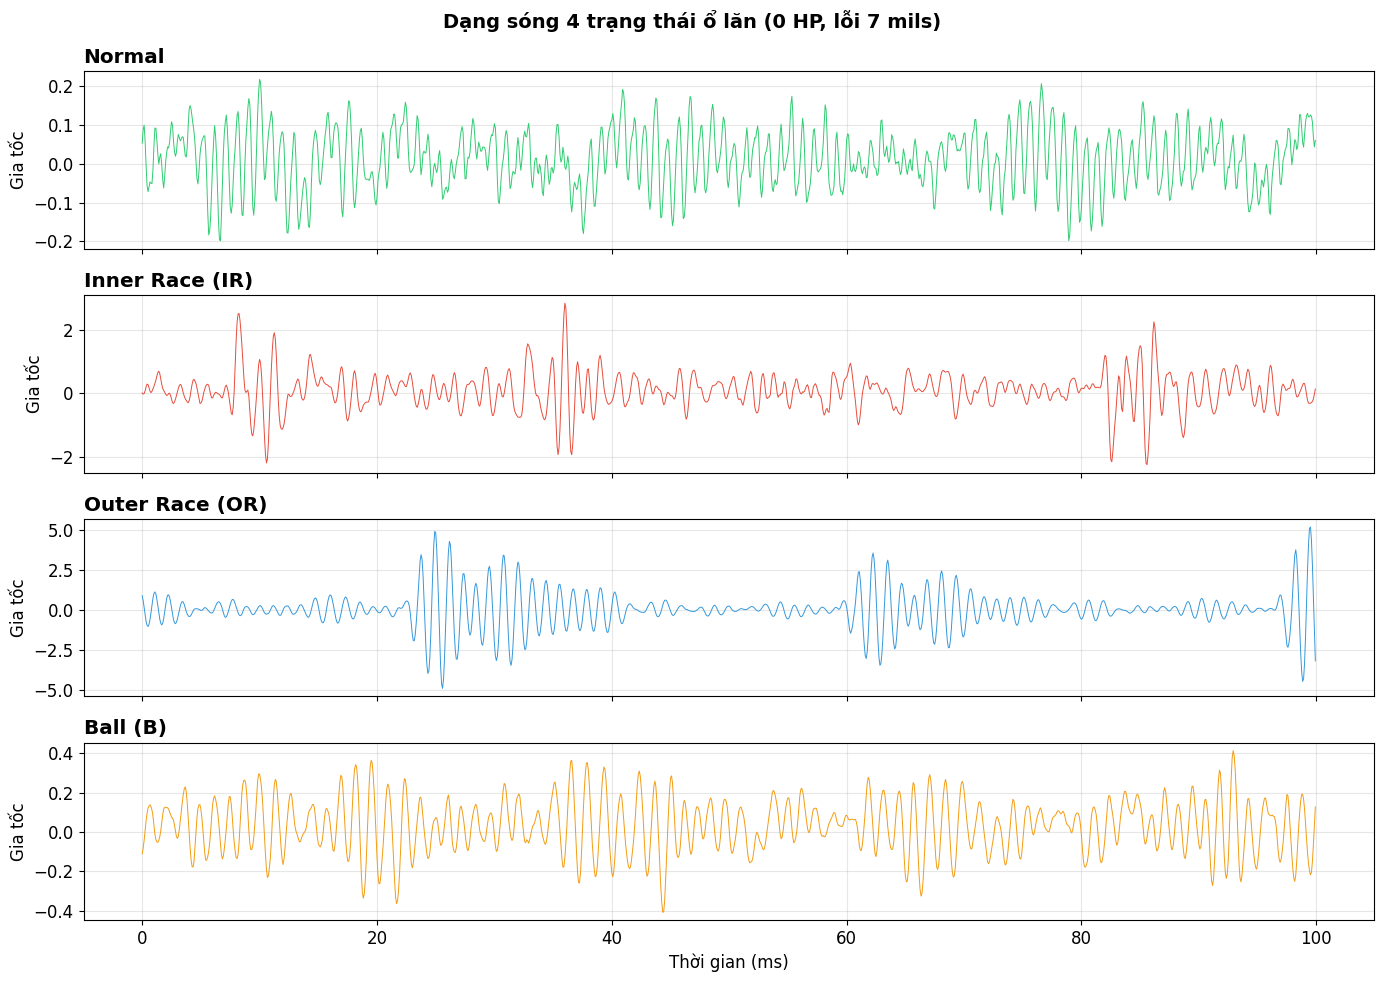

In [4]:
# Đọc thêm OR và B
or_007 = np.load(os.path.join(DATA_ROOT, "0HP", "OR_007@6_DE.npy"))
b_007  = np.load(os.path.join(DATA_ROOT, "0HP", "B_007_DE.npy"))

signals = {'Normal': normal, 'Inner Race (IR)': ir_007, 
           'Outer Race (OR)': or_007, 'Ball (B)': b_007}
colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12']

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
for ax, (name, sig), clr in zip(axes, signals.items(), colors):
    ax.plot(t, sig[:n_show], color=clr, linewidth=0.7)
    ax.set_ylabel('Gia tốc')
    ax.set_title(name, fontweight='bold', loc='left')
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('Thời gian (ms)')
plt.suptitle('Dạng sóng 4 trạng thái ổ lăn (0 HP, lỗi 7 mils)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 4. Zoom vào vùng xung va chạm

Khi ổ lăn hỏng, mỗi lần viên bi lăn qua vết lỗi tạo ra 1 xung. Ta zoom vào để thấy rõ.


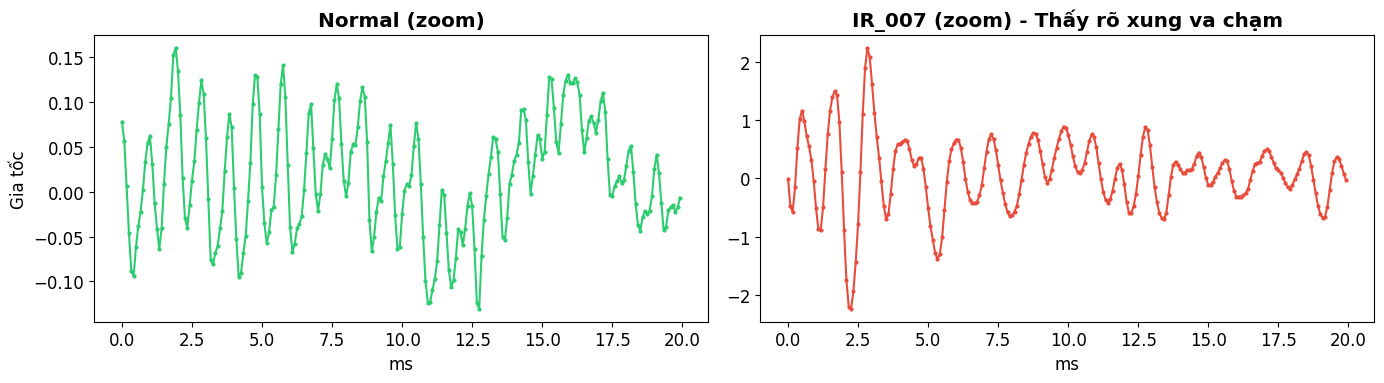

Khoảng cách giữa các xung ≈ chu kỳ BPFI (Ball Pass Frequency Inner)


In [5]:
# Zoom vào 0.02 giây (240 mẫu) của tín hiệu IR
n_zoom = 240
t_zoom = np.arange(n_zoom) / SAMPLE_RATE * 1000

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Normal - zoom
axes[0].plot(t_zoom, normal[1000:1000+n_zoom], 'o-', color='#2ecc71', markersize=2)
axes[0].set_title('Normal (zoom)', fontweight='bold')
axes[0].set_xlabel('ms')
axes[0].set_ylabel('Gia tốc')

# IR - zoom
axes[1].plot(t_zoom, ir_007[1000:1000+n_zoom], 'o-', color='#e74c3c', markersize=2)
axes[1].set_title('IR_007 (zoom) - Thấy rõ xung va chạm', fontweight='bold')
axes[1].set_xlabel('ms')

plt.tight_layout()
plt.show()

print("Khoảng cách giữa các xung ≈ chu kỳ BPFI (Ball Pass Frequency Inner)")


## 5. Thống kê cơ bản

So sánh nhanh các giá trị thống kê giữa 4 trạng thái.


In [6]:
print(f"{'Trạng thái':<20} {'Mean':>10} {'Std':>10} {'Max':>10} {'Min':>10}")
print("-" * 62)
for name, sig in signals.items():
    s = sig[:120000]  # lấy 10 giây
    print(f"{name:<20} {np.mean(s):>10.4f} {np.std(s):>10.4f} {np.max(s):>10.4f} {np.min(s):>10.4f}")

print("\nNhận xét: Std và Max/Min tăng rõ khi có lỗi → biên độ rung tăng")


Trạng thái                 Mean        Std        Max        Min
--------------------------------------------------------------
Normal                   0.0123     0.0719     0.3113    -0.2866
Inner Race (IR)          0.0800     0.5827     3.2915    -2.7736
Outer Race (OR)          0.0113     1.2575     6.5413    -6.1490
Ball (B)                 0.0325     0.1473     0.7324    -0.6006

Nhận xét: Std và Max/Min tăng rõ khi có lỗi → biên độ rung tăng


## 📝 Bài tập

1. Đọc file `IR_021_DE.npy` (lỗi nặng hơn) và so sánh waveform với `IR_007_DE.npy`
2. So sánh cùng loại lỗi ở các mức tải khác nhau (0HP vs 3HP)
3. Tín hiệu nào khó phân biệt nhất với Normal? Tại sao?

---
*Tutorial 01/05 – Khóa đào tạo "Ứng dụng ML trong chẩn đoán thiết bị quay"*
